# Эксперимент 6: Синтетика + правильное соотношение сторон (224×1400)

**Комбинация находок Эксп.3 и Эксп.5:**
- Вход: 224×1400 (соотношение 1:6.25, как у оригинала 256×1600)
- Синтетика: реальный фон + вставленные дефекты классов 1 и 2
- Веса: всегда от реальных данных (фикс из Эксп.3)
- Данные: 200 реальных изображений

**Гипотеза:** синтетика не работала раньше в том числе потому,
что квадратный resize 518×518 уничтожал горизонтальную структуру
вставленных дефектов. С правильным размером синтетика должна помочь.

> **v2** — исправлен баг: `JointTransform` применяет flip и crop **одновременно** к изображению и маске.

## 1. Импорты и конфигурация

In [1]:
import os, random, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm
from collections import Counter
import cv2, sys

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchmetrics import JaccardIndex
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

print(f'Python: {sys.version}')
print(f'PyTorch: {torch.__version__}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

DATA_DIR      = 'C:/Users/ADMIN/Desktop/magistr/VKR/steel_defect/'
TRAIN_CSV     = os.path.join(DATA_DIR, 'train.csv')
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train_images/')
save_dir      = 'C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads'
os.makedirs(save_dir, exist_ok=True)

# ── Размеры (правильное соотношение сторон) ────────────────────────────
IMG_H      = 224
IMG_W      = 1400
PATCH_H    = IMG_H // 14   # 16
PATCH_W    = IMG_W // 14   # 100
MASK_H     = PATCH_H * 4   # 64
MASK_W     = PATCH_W * 4   # 400
EMBED_DIM  = 768
NUM_CLASSES = 5
# ───────────────────────────────────────────────────────────────────────

BATCH_SIZE  = 4
EPOCHS      = 75
LR_HEAD     = 1e-3
N_SELECT    = 200
TEST_SIZE   = 0.2
IMG_H_ORIG  = 256
IMG_W_ORIG  = 1600

print(f'Вход: {IMG_H}x{IMG_W}, патчи: {PATCH_H}x{PATCH_W}, маска: {MASK_H}x{MASK_W}')

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
PyTorch: 2.12.0.dev20260408+cu128
Устройство: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Вход: 224x1400, патчи: 16x100, маска: 64x400


## 2. Датасет и вспомогательные функции

In [2]:
train_df    = pd.read_csv(TRAIN_CSV)
labeled_ids = train_df['ImageId'].unique().tolist()
print(f'Изображений: {len(labeled_ids):,}')


def decode_rle(rle_string, shape=(256, 1600)):
    if pd.isna(rle_string) or not isinstance(rle_string, str):
        return np.zeros(shape, dtype=np.uint8)
    nums   = list(map(int, rle_string.strip().split()))
    starts = np.array(nums[0::2]) - 1
    lens   = np.array(nums[1::2])
    mask   = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    for s, l in zip(starts, lens):
        mask[s:s+l] = 1
    return mask.reshape(shape, order='F')


def build_segmask(image_id, df, shape=(256, 1600)):
    mask = np.zeros(shape, dtype=np.uint8)
    for _, row in df[df['ImageId'] == image_id].iterrows():
        cls = int(row['ClassId'])
        m   = decode_rle(row['EncodedPixels'], shape)
        mask[m == 1] = cls
    return mask


def get_classes(img_id, df):
    rows = df[df['ImageId'] == img_id]
    return sorted(rows['ClassId'].dropna().astype(int).unique().tolist())


def get_label(img_id, df):
    cls = get_classes(img_id, df)
    return cls[0] if cls else 0


def compute_class_weights(image_ids, df, num_classes=NUM_CLASSES):
    """Веса всегда от реальных данных — синтетика не учитывается."""
    px = Counter({c: 0 for c in range(num_classes)})
    for img_id in image_ids:
        mask = build_segmask(img_id, df)
        for c in range(num_classes):
            px[c] += int((mask == c).sum())
    total = sum(px.values())
    w = torch.tensor([total/(num_classes*(px[c]+1e-6)) for c in range(num_classes)])
    w = (w / w.mean()).clamp(min=0.1, max=5.0)
    print('Веса классов (от реальных данных):')
    for c, v in enumerate(w):
        print(f'  {"Фон" if c==0 else f"Дефект {c}"}: {v:.3f}  ({px[c]:,} пикс.)')
    return w.to(DEVICE)


print('Вспомогательные функции определены.')

Изображений: 6,666
Вспомогательные функции определены.


## 3. Dataset-классы

In [3]:
# v2: JointTransform — flip и crop применяются к img и mask одновременно
FLIP_P      = 0.5
CROP_SCALE  = (0.85, 1.0)
BRIGHTNESS  = 0.3


class JointTransform:
    def __init__(self, img_h=IMG_H, img_w=IMG_W, is_train=True,
                 flip_p=FLIP_P, crop_scale=CROP_SCALE, brightness=BRIGHTNESS):
        self.img_h       = img_h
        self.img_w       = img_w
        self.is_train    = is_train
        self.flip_p      = flip_p
        self.crop_scale  = crop_scale
        self.color_jitter = transforms.ColorJitter(brightness=brightness)
        self.to_tensor   = transforms.ToTensor()
        self.normalize   = transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __call__(self, img_pil, mask_np):
        img_pil  = img_pil.resize((self.img_w, self.img_h), Image.BILINEAR)
        mask_pil = Image.fromarray(mask_np).resize(
            (self.img_w, self.img_h), Image.NEAREST)
        if self.is_train:
            if random.random() < self.flip_p:
                img_pil  = img_pil.transpose(Image.FLIP_LEFT_RIGHT)
                mask_pil = mask_pil.transpose(Image.FLIP_LEFT_RIGHT)
            scale  = random.uniform(*self.crop_scale)
            crop_h = max(1, int(self.img_h * scale))
            crop_w = max(1, int(self.img_w * scale))
            top    = random.randint(0, self.img_h - crop_h)
            left   = random.randint(0, self.img_w - crop_w)
            img_pil  = img_pil.crop((left, top, left+crop_w, top+crop_h))
            mask_pil = mask_pil.crop((left, top, left+crop_w, top+crop_h))
            img_pil  = img_pil.resize((self.img_w, self.img_h), Image.BILINEAR)
            mask_pil = mask_pil.resize((self.img_w, self.img_h), Image.NEAREST)
            img_pil  = self.color_jitter(img_pil)
        img_t    = self.normalize(self.to_tensor(img_pil))
        mask_np2 = np.array(mask_pil, dtype=np.uint8)
        return img_t, mask_np2


train_jt = JointTransform(is_train=True)
val_jt   = JointTransform(is_train=False)


class SteelSegDataset(Dataset):
    def __init__(self, ids, img_dir, df, joint_transform):
        self.ids=ids; self.img_dir=img_dir; self.df=df
        self.jt=joint_transform
    def __len__(self): return len(self.ids)
    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img    = Image.open(os.path.join(self.img_dir, img_id)).convert('RGB')
        mask   = build_segmask(img_id, self.df)
        img_t, mask_np = self.jt(img, mask)
        mask_t = torch.from_numpy(mask_np).unsqueeze(0).float()
        mask_t = F.interpolate(mask_t.unsqueeze(0),
                               size=(MASK_H, MASK_W),
                               mode='nearest').squeeze().long()
        return img_t, mask_t, img_id


class SteelSegDatasetWithSynth(Dataset):
    def __init__(self, ids, img_dir, df, joint_transform, synth=None):
        self.ids=ids; self.img_dir=img_dir; self.df=df
        self.jt=joint_transform; self.synth=synth or []
    def __len__(self): return len(self.ids) + len(self.synth)
    def __getitem__(self, idx):
        if idx < len(self.ids):
            img_id = self.ids[idx]
            img    = Image.open(os.path.join(self.img_dir, img_id)).convert('RGB')
            mask   = build_segmask(img_id, self.df)
        else:
            img_arr, mask = self.synth[idx - len(self.ids)]
            img = Image.fromarray(img_arr)
        img_t, mask_np = self.jt(img, mask)
        mask_t = torch.from_numpy(mask_np).unsqueeze(0).float()
        mask_t = F.interpolate(mask_t.unsqueeze(0),
                               size=(MASK_H, MASK_W),
                               mode='nearest').squeeze().long()
        return img_t, mask_t, str(idx)


print('Dataset-классы определены.')
print(f'Аугментации: flip_p={FLIP_P}, crop={CROP_SCALE}, brightness={BRIGHTNESS}')

Dataset-классы определены.
Аугментации: flip_p=0.5, crop=(0.85, 1.0), brightness=0.3


## 4. Загрузка DINOv2 (заморожен)

In [4]:
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14',
                        pretrained=True, verbose=False)
dinov2 = dinov2.to(DEVICE).eval()
for p in dinov2.parameters():
    p.requires_grad = False
print(f'DINOv2: {sum(p.numel() for p in dinov2.parameters())/1e6:.1f}М параметров (заморожен)')

# Проверка нестандартного размера входа
with torch.no_grad():
    _t = torch.randn(1, 3, IMG_H, IMG_W).to(DEVICE)
    _o = dinov2.forward_features(_t)['x_norm_patchtokens']
print(f'Тест: вход {IMG_H}x{IMG_W} -> токены {_o.shape} (ожидалось {PATCH_H*PATCH_W})')
assert _o.shape == (1, PATCH_H*PATCH_W, EMBED_DIM)
del _t, _o
print('OK')

C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2: 86.6М параметров (заморожен)
Тест: вход 224x1400 -> токены torch.Size([1, 1600, 768]) (ожидалось 1600)
OK


## 5. Эмбеддинги и отбор 200 изображений

In [5]:
emb_cache = os.path.join(save_dir, 'embeddings.pt')
ckpt       = torch.load(emb_cache, map_location='cpu')
embeddings = ckpt['embeddings']
emb_ids    = ckpt['emb_ids']
print(f'Эмбеддинги загружены из кэша: {embeddings.shape}')


def lightly_active_select(embeddings, image_ids, n_select, seed=SEED):
    km = KMeans(n_clusters=n_select, random_state=seed, n_init=10)
    km.fit(embeddings.numpy())
    sel = []
    for k in range(n_select):
        m  = km.labels_ == k
        if not m.any(): continue
        c  = torch.tensor(km.cluster_centers_[k])
        ix = np.where(m)[0]
        sel.append(int(ix[torch.norm(embeddings[m]-c, dim=1).argmin().item()]))
    return [image_ids[i] for i in sel], sel


def stratified_active_select(embeddings, image_ids, df,
                              n_per_class=25, n_total=200):
    guaranteed = []
    for cls in [1, 2, 3, 4]:
        cids = [i for i in image_ids if cls in get_classes(i, df)]
        guaranteed.extend(random.sample(cids, min(n_per_class, len(cids))))
    guaranteed = list(set(guaranteed))
    remaining  = [i for i in image_ids if i not in guaranteed]
    n_km       = n_total - len(guaranteed)
    extra      = []
    if n_km > 0 and remaining:
        rm    = [image_ids.index(i) for i in remaining]
        extra, _ = lightly_active_select(embeddings[rm], remaining, n_km)
    result = guaranteed + extra
    print(f'Отбор: {len(guaranteed)} гарант. + {len(extra)} KMeans = {len(result)}')
    return result


all_labels  = [get_label(i, train_df) for i in labeled_ids]
train_ids, test_ids = train_test_split(
    labeled_ids, test_size=TEST_SIZE, stratify=all_labels, random_state=SEED)
print(f'Train pool: {len(train_ids):,}  |  Test: {len(test_ids):,}')

pool_mask    = [emb_ids.index(i) for i in train_ids]
pool_embeds  = embeddings[pool_mask]
selected_ids = stratified_active_select(
    pool_embeds, train_ids, train_df, n_per_class=25, n_total=N_SELECT)

Эмбеддинги загружены из кэша: torch.Size([6666, 768])
Train pool: 5,332  |  Test: 1,334
Отбор: 99 гарант. + 101 KMeans = 200


## 6. Архитектура SegHeadNonSquare + DiceLoss

In [6]:
class SegHeadNonSquare(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
                 patch_h=PATCH_H, patch_w=PATCH_W):
        super().__init__()
        self.patch_h = patch_h
        self.patch_w = patch_w
        self.decoder = nn.Sequential(
            nn.Conv2d(embed_dim, 256, 1),
            nn.BatchNorm2d(256), nn.GELU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.GELU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, num_classes, 1),
        )
    def forward(self, pt):
        B, N, C = pt.shape
        x = pt.reshape(B, self.patch_h, self.patch_w, C).permute(0,3,1,2)
        return self.decoder(x)


class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__(); self.s=smooth
    def forward(self, logits, targets):
        p       = F.softmax(logits, dim=1)
        B,C,H,W = p.shape
        t       = F.one_hot(targets, C).permute(0,3,1,2).float()
        i       = (p*t).sum(dim=(2,3))
        u       = p.sum(dim=(2,3)) + t.sum(dim=(2,3))
        return 1 - ((2*i+self.s)/(u+self.s)).mean()


_h = SegHeadNonSquare().to(DEVICE)
print(f'SegHeadNonSquare: {sum(p.numel() for p in _h.parameters()):,} параметров')
with torch.no_grad():
    _d = torch.randn(2, PATCH_H*PATCH_W, EMBED_DIM).to(DEVICE)
    _o = _h(_d)
print(f'Выход: {tuple(_o.shape)}  (ожидалось: (2, {NUM_CLASSES}, {MASK_H}, {MASK_W}))')
del _h, _d, _o

SegHeadNonSquare: 566,917 параметров
Выход: (2, 5, 64, 400)  (ожидалось: (2, 5, 64, 400))


## 7. Функции генерации синтетики

In [7]:
def extract_defect_patch(img_id, df, img_dir, cls):
    img  = np.array(Image.open(os.path.join(img_dir, img_id)).convert('RGB'))
    mask = build_segmask(img_id, df)
    px   = np.where(mask == cls)
    if len(px[0]) < 5: return None, None
    y0,y1 = px[0].min(), px[0].max()
    x0,x1 = px[1].min(), px[1].max()
    pi = img[y0:y1+1, x0:x1+1].copy()
    pm = mask[y0:y1+1, x0:x1+1].copy()
    not_def = (pm != cls)
    pi[not_def] = 0; pm[not_def] = 0
    return pi, pm


def rotate_defect(patch_img, patch_mask, angle_deg):
    h,w   = patch_img.shape[:2]
    cx,cy = w//2, h//2
    M     = cv2.getRotationMatrix2D((cx,cy), angle_deg, 1.0)
    cos_a, sin_a = abs(M[0,0]), abs(M[0,1])
    nw = int(h*sin_a+w*cos_a); nh = int(h*cos_a+w*sin_a)
    M[0,2]+=nw/2-cx; M[1,2]+=nh/2-cy
    ri = cv2.warpAffine(patch_img, M, (nw,nh),
                        flags=cv2.INTER_LINEAR,
                        borderMode=cv2.BORDER_CONSTANT, borderValue=0)
    rm = cv2.warpAffine(patch_mask.astype(np.uint8), M, (nw,nh),
                        flags=cv2.INTER_NEAREST,
                        borderMode=cv2.BORDER_CONSTANT, borderValue=0)
    return ri, rm


def stitch_defects(img1, mask1, img2, mask2, cls, overlap=5):
    def pad_to(a, h):
        if a.shape[0]==h: return a
        return np.pad(a, [(0,h-a.shape[0])]+[(0,0)]*(a.ndim-1))
    c1 = np.where(np.any(mask1==cls, axis=0))[0]
    c2 = np.where(np.any(mask2==cls, axis=0))[0]
    if len(c1)==0 or len(c2)==0:
        h = max(img1.shape[0], img2.shape[0])
        return np.hstack([pad_to(img1,h),pad_to(img2,h)]), \
               np.hstack([pad_to(mask1,h),pad_to(mask2,h)])
    i1=img1[:,:c1.max()+1]; m1=mask1[:,:c1.max()+1]
    i2=img2[:,c2.min():];   m2=mask2[:,c2.min():]
    h = max(i1.shape[0], i2.shape[0])
    i1,m1,i2,m2 = pad_to(i1,h),pad_to(m1,h),pad_to(i2,h),pad_to(m2,h)
    if overlap>0 and i1.shape[1]>overlap and i2.shape[1]>overlap:
        alpha = np.linspace(1,0,overlap)[np.newaxis,:,np.newaxis]
        i1[:,-overlap:] = (i1[:,-overlap:]*alpha+i2[:,:overlap]*(1-alpha)).astype(np.uint8)
    return np.hstack([i1,i2]), np.hstack([m1,m2])


def pick_real_background(image_ids, df, img_dir):
    """Реальное изображение как фон — с его оригинальной маской."""
    img_id = random.choice(image_ids)
    img    = np.array(Image.open(os.path.join(img_dir, img_id)).convert('RGB'))
    mask   = build_segmask(img_id, df)
    return img, mask


def paste_on_real_background(bg_img, bg_mask, def_img, def_mask,
                              cls, max_attempts=50):
    """Вставляет дефект в свободную область реального изображения."""
    H,W = bg_img.shape[:2]
    h,w = def_img.shape[:2]
    do  = (def_mask == cls)
    if h >= H or w >= W or do.sum() < 5:
        return bg_img, bg_mask
    ri = bg_img.copy(); rm = bg_mask.copy()
    for _ in range(max_attempts):
        y = random.randint(0, H-h-1)
        x = random.randint(0, W-w-1)
        if np.all(rm[y:y+h, x:x+w][do] == 0):
            ri[y:y+h, x:x+w][do] = def_img[do]
            rm[y:y+h, x:x+w][do] = cls
            return ri, rm
    return ri, rm


def generate_synthetic(selected_ids, all_ids, df, img_dir,
                        target_pixels, cls_list=[1,2],
                        angles=[-15,-10,-5,0,5,10,15]):
    """Генерирует синтетику на реальных фонах.
    Изображения хранятся в оригинальном разрешении 256x1600 —
    правильный ресайз применяется во время обучения через transform."""
    sources = {c:[i for i in selected_ids if c in get_classes(i,df)]
               for c in cls_list}
    for c in cls_list:
        print(f'  Источников класса {c}: {len(sources[c])}')
    synth=[]; total_px=0; n_gen=0; n_skip=0
    print(f'Цель: {target_pixels:,} пикселей')
    while total_px < target_pixels:
        cls = random.choice(cls_list)
        if not sources[cls]: continue
        bg_img, bg_mask = pick_real_background(all_ids, df, img_dir)
        id1 = random.choice(sources[cls])
        id2 = random.choice(sources[cls])
        p1i,p1m = extract_defect_patch(id1, df, img_dir, cls)
        p2i,p2m = extract_defect_patch(id2, df, img_dir, cls)
        if p1i is None or p2i is None: continue
        p1i,p1m = rotate_defect(p1i, p1m, random.choice(angles))
        p2i,p2m = rotate_defect(p2i, p2m, random.choice(angles))
        ci,cm   = stitch_defects(p1i, p1m, p2i, p2m, cls, overlap=5)
        ri,rm   = paste_on_real_background(bg_img, bg_mask, ci, cm, cls)
        n_px    = int((rm==cls).sum())
        if n_px < 10: n_skip+=1; continue
        synth.append((ri, rm)); total_px+=n_px; n_gen+=1
        if n_gen % 20 == 0:
            print(f'  {n_gen} изобр. | {total_px:,}/{target_pixels:,}')
    print(f'Готово: {n_gen} изображений, {total_px:,} пикселей (пропущено: {n_skip})')
    return synth


print('Функции синтетики определены.')

Функции синтетики определены.


## 8. Генерация синтетики (с кэшированием)

In [8]:
synth_cache = os.path.join(save_dir, 'synth_pairs.pkl')

if os.path.exists(synth_cache):
    print('Загружаем синтетику из кэша...')
    with open(synth_cache, 'rb') as f:
        synth_pairs = pickle.load(f)
    print(f'Загружено: {len(synth_pairs)} пар')
    # Проверяем размер изображений в кэше
    h, w = synth_pairs[0][0].shape[:2]
    print(f'Размер в кэше: {h}x{w} (будет ресайзен к {IMG_H}x{IMG_W} через transform)')
else:
    px_cls3 = sum(int((build_segmask(i, train_df)==3).sum())
                  for i in selected_ids)
    print(f'Пикселей класса 3 в {N_SELECT} примерах: {px_cls3:,}')
    synth_pairs = generate_synthetic(
        selected_ids=selected_ids,
        all_ids=labeled_ids,
        df=train_df,
        img_dir=TRAIN_IMG_DIR,
        target_pixels=px_cls3,
        cls_list=[1, 2],
    )
    with open(synth_cache, 'wb') as f:
        pickle.dump(synth_pairs, f)
    print(f'Синтетика сохранена: {synth_cache}')

print(f'\nИтого: {N_SELECT} реальных + {len(synth_pairs)} синтетических '
      f'= {N_SELECT+len(synth_pairs)} изображений')

Загружаем синтетику из кэша...
Загружено: 461 пар
Размер в кэше: 256x1600 (будет ресайзен к 224x1400 через transform)

Итого: 200 реальных + 461 синтетических = 661 изображений


## 9. Функция обучения

In [9]:
def train_head(train_ids, val_ids, df, synth=None,
               n_epochs=EPOCHS, lr=LR_HEAD, label='',
               checkpoint_every=25):
    head  = SegHeadNonSquare().to(DEVICE)
    opt   = optim.AdamW(head.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    # Веса всегда от реальных данных
    cw    = compute_class_weights(train_ids, df)
    cce   = nn.CrossEntropyLoss(weight=cw)
    cdice = DiceLoss()

    if synth:
        tds = SteelSegDatasetWithSynth(
            train_ids, TRAIN_IMG_DIR, df, train_jt, synth=synth)
    else:
        tds = SteelSegDataset(train_ids, TRAIN_IMG_DIR, df, train_jt)
    vds = SteelSegDataset(val_ids, TRAIN_IMG_DIR, df, val_jt)

    tdl = DataLoader(tds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    vdl = DataLoader(vds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    iou  = JaccardIndex(task='multiclass', num_classes=NUM_CLASSES,
                        average='none').to(DEVICE)
    hist = {'train_loss':[], 'val_miou':[], 'val_iou_per_class':[]}
    best = 0.0
    print(f'Обучающих: {len(tds)}  |  Валидационных: {len(vds)}')

    for ep in range(1, n_epochs+1):
        head.train(); tl = 0.0
        for imgs, masks, _ in tdl:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            with torch.no_grad():
                pts = dinov2.forward_features(imgs)['x_norm_patchtokens']
            lg   = head(pts)
            loss = cce(lg, masks) + 0.5*cdice(lg, masks)
            opt.zero_grad(); loss.backward(); opt.step()
            tl  += loss.item()
        sched.step()

        head.eval(); iou.reset()
        with torch.no_grad():
            for imgs, masks, _ in vdl:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                pts = dinov2.forward_features(imgs)['x_norm_patchtokens']
                iou.update(head(pts).argmax(1), masks)
        ipc = iou.compute().cpu().numpy()
        mi  = float(ipc.mean())
        hist['train_loss'].append(tl/len(tdl))
        hist['val_miou'].append(mi)
        hist['val_iou_per_class'].append(ipc.tolist())
        if mi > best: best = mi

        if ep % 10 == 0 or ep == 1:
            s = '  '.join([f'cls{i}:{v:.3f}' for i,v in enumerate(ipc)])
            print(f'[{label}] Эп {ep:3d}/{n_epochs} | '
                  f'Loss:{tl/len(tdl):.4f} | mIoU:{mi:.4f} | {s}')

        if ep % checkpoint_every == 0:
            ckpt_path = os.path.join(save_dir, f'ckpt_{label}_v2_ep{ep}.pt')
            torch.save({'epoch':ep, 'model_state':head.state_dict(),
                        'history':hist, 'best_miou':best}, ckpt_path)
            print(f'  Чекпоинт: {ckpt_path}')

    print(f'\n  -> Лучший mIoU: {best:.4f}')
    return head, hist


print('Функция обучения определена.')

Функция обучения определена.


## 10. Базовое обучение — 200 реальных (без синтетики)

In [10]:
print('='*60)
print('БАЗОВОЕ (200 реальных, 224x1400) — повтор Эксп.5')
print('='*60)
model_base, history_base6 = train_head(
    selected_ids, test_ids, train_df,
    synth=None, label='Base-224x1400')

БАЗОВОЕ (200 реальных, 224x1400) — повтор Эксп.5
Веса классов (от реальных данных):
  Фон: 0.100  (77,617,072 пикс.)
  Дефект 1: 1.888  (175,291 пикс.)
  Дефект 2: 2.722  (121,580 пикс.)
  Дефект 3: 0.120  (2,760,536 пикс.)
  Дефект 4: 0.266  (1,245,521 пикс.)
Обучающих: 200  |  Валидационных: 1334
[Base-224x1400] Эп   1/75 | Loss:1.3280 | mIoU:0.3594 | cls0:0.909  cls1:0.028  cls2:0.036  cls3:0.394  cls4:0.429
[Base-224x1400] Эп  10/75 | Loss:0.4810 | mIoU:0.4520 | cls0:0.952  cls1:0.162  cls2:0.130  cls3:0.475  cls4:0.542
[Base-224x1400] Эп  20/75 | Loss:0.2567 | mIoU:0.4296 | cls0:0.946  cls1:0.126  cls2:0.082  cls3:0.448  cls4:0.547
  Чекпоинт: C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads\ckpt_Base-224x1400_v2_ep25.pt
[Base-224x1400] Эп  30/75 | Loss:0.2071 | mIoU:0.4757 | cls0:0.957  cls1:0.227  cls2:0.225  cls3:0.434  cls4:0.535
[Base-224x1400] Эп  40/75 | Loss:0.1451 | mIoU:0.4866 | cls0:0.957  cls1:0.242  cls2:0.209  cls3:0.480  cls4:0.546
[Base-224x1400] Эп  50/75 | Loss:0.12

## 11. Обучение с синтетикой

In [11]:
print('='*60)
print(f'С СИНТЕТИКОЙ ({N_SELECT} реал. + {len(synth_pairs)} синт., 224x1400)')
print('='*60)
model_syn, history_syn6 = train_head(
    selected_ids, test_ids, train_df,
    synth=synth_pairs,
    label=f'Synth-224x1400-{N_SELECT}+{len(synth_pairs)}')

С СИНТЕТИКОЙ (200 реал. + 461 синт., 224x1400)
Веса классов (от реальных данных):
  Фон: 0.100  (77,617,072 пикс.)
  Дефект 1: 1.888  (175,291 пикс.)
  Дефект 2: 2.722  (121,580 пикс.)
  Дефект 3: 0.120  (2,760,536 пикс.)
  Дефект 4: 0.266  (1,245,521 пикс.)
Обучающих: 661  |  Валидационных: 1334
[Synth-224x1400-200+461] Эп   1/75 | Loss:0.9361 | mIoU:0.3840 | cls0:0.944  cls1:0.079  cls2:0.038  cls3:0.414  cls4:0.445
[Synth-224x1400-200+461] Эп  10/75 | Loss:0.3717 | mIoU:0.4087 | cls0:0.936  cls1:0.099  cls2:0.081  cls3:0.446  cls4:0.482
[Synth-224x1400-200+461] Эп  20/75 | Loss:0.2883 | mIoU:0.4749 | cls0:0.960  cls1:0.222  cls2:0.110  cls3:0.513  cls4:0.569
  Чекпоинт: C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads\ckpt_Synth-224x1400-200+461_v2_ep25.pt
[Synth-224x1400-200+461] Эп  30/75 | Loss:0.2159 | mIoU:0.4991 | cls0:0.961  cls1:0.220  cls2:0.210  cls3:0.520  cls4:0.584
[Synth-224x1400-200+461] Эп  40/75 | Loss:0.1913 | mIoU:0.5039 | cls0:0.955  cls1:0.248  cls2:0.227  cls3:0.5

## 12. Итоговое сравнение

ИТОГОВОЕ СРАВНЕНИЕ:
  Эксп.5  Базовый    (200 реал., 224x1400):  mIoU = 0.5004
  Эксп.6  Базовый    (200 реал., 224x1400):  mIoU = 0.5067
  Эксп.6  Синтетика  (200+461 синт., 224x1400): mIoU = 0.5303
  Прирост синтетики: +2.4%

  Класс          Эксп.6 Баз    Эксп.6 Синт    Прирост
----------------------------------------------------
  Фон                0.9598         0.9633      +0.4%
  Дефект 1           0.2744         0.3079      +3.3%
  Дефект 2           0.2823         0.2667      -1.6%
  Дефект 3           0.4586         0.5230      +6.4%
  Дефект 4           0.5583         0.5909      +3.3%


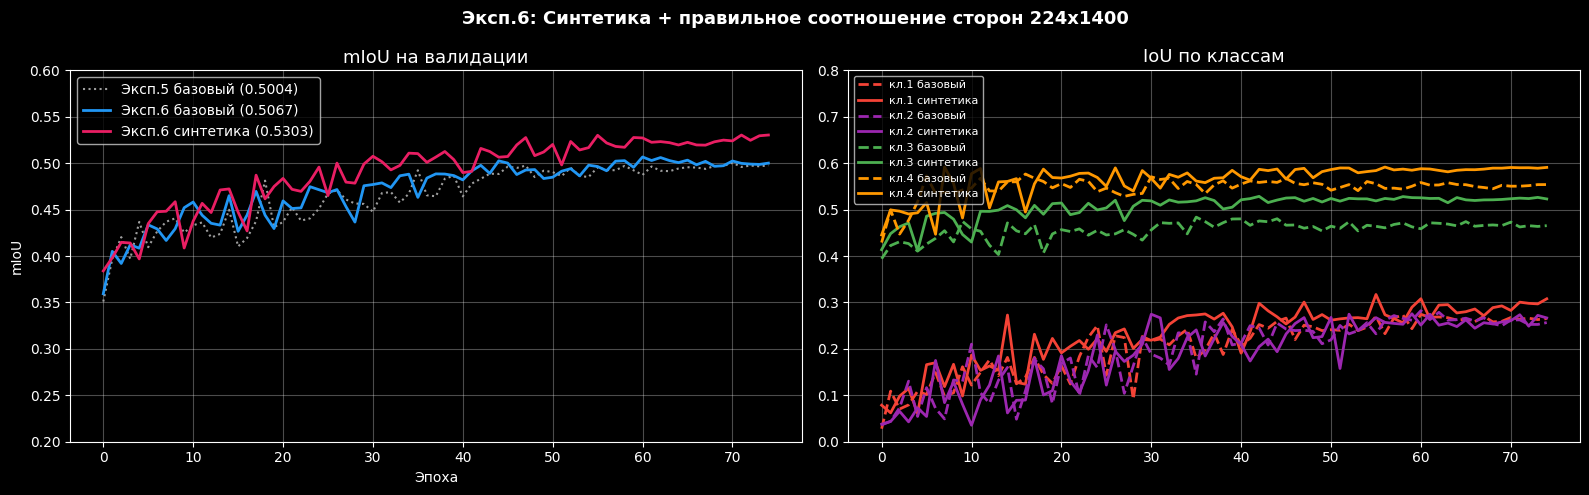

In [12]:
import numpy as np

def best_epoch(hist):
    ep = int(np.argmax(hist['val_miou']))
    return max(hist['val_miou']), hist['val_iou_per_class'][ep]

mb6, ib6 = best_epoch(history_base6)
ms6, is6 = best_epoch(history_syn6)

# Загружаем Эксп.5 для контекста
hist_ar_path = os.path.join(save_dir, 'history_ar_v2.json')
if os.path.exists(hist_ar_path):
    with open(hist_ar_path) as f:
        hist_ar = json.load(f)
    mar, iar = best_epoch(hist_ar)
    has_ar = True
else:
    has_ar = False

names = ['Фон','Дефект 1','Дефект 2','Дефект 3','Дефект 4']
print('='*65)
print('ИТОГОВОЕ СРАВНЕНИЕ:')
if has_ar:
    print(f'  Эксп.5  Базовый    (200 реал., 224x1400):  mIoU = {mar:.4f}')
print(f'  Эксп.6  Базовый    (200 реал., 224x1400):  mIoU = {mb6:.4f}')
print(f'  Эксп.6  Синтетика  (200+{len(synth_pairs)} синт., 224x1400): mIoU = {ms6:.4f}')
print(f'  Прирост синтетики: {(ms6-mb6)*100:+.1f}%')
print()
print(f'  {"Класс":<12} {"Эксп.6 Баз":>12} {"Эксп.6 Синт":>14} {"Прирост":>10}')
print('-'*52)
for c,(b,s) in enumerate(zip(ib6, is6)):
    print(f'  {names[c]:<12} {b:>12.4f} {s:>14.4f} {(s-b)*100:>+9.1f}%')

# График
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
if has_ar:
    axes[0].plot(hist_ar['val_miou'], color='#9E9E9E', lw=1.5, ls=':',
                 label=f'Эксп.5 базовый ({mar:.4f})')
axes[0].plot(history_base6['val_miou'], color='#2196F3', lw=2,
             label=f'Эксп.6 базовый ({mb6:.4f})')
axes[0].plot(history_syn6['val_miou'], color='#E91E63', lw=2,
             label=f'Эксп.6 синтетика ({ms6:.4f})')
axes[0].set_title('mIoU на валидации', fontsize=13)
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('mIoU')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_ylim(0.2, 0.6)

colors_cls = {1:'#F44336', 2:'#9C27B0', 3:'#4CAF50', 4:'#FF9800'}
for cls, col in colors_cls.items():
    b_c = [h[cls] for h in history_base6['val_iou_per_class']]
    s_c = [h[cls] for h in history_syn6['val_iou_per_class']]
    axes[1].plot(b_c, color=col, lw=2, ls='--', label=f'кл.{cls} базовый')
    axes[1].plot(s_c, color=col, lw=2, ls='-',  label=f'кл.{cls} синтетика')
axes[1].set_title('IoU по классам', fontsize=13)
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3); axes[1].set_ylim(0, 0.8)
plt.suptitle('Эксп.6: Синтетика + правильное соотношение сторон 224x1400',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 13. Сохранение

In [13]:
torch.save(model_base.state_dict(),
           os.path.join(save_dir, 'model_base6_224x1400_v2.pt'))
torch.save(model_syn.state_dict(),
           os.path.join(save_dir, 'model_syn6_224x1400_v2.pt'))
with open(os.path.join(save_dir, 'history_base6_v2.json'), 'w') as f:
    json.dump(history_base6, f)
with open(os.path.join(save_dir, 'history_syn6_v2.json'), 'w') as f:
    json.dump(history_syn6, f)
print(f'Всё сохранено в: {save_dir}')

Всё сохранено в: C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads
